In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#workclass - Private, Self-emp-not-inc, Local-gov, State-gov
#marital.status - Married-civ-spouse, Widowed, Divorced, Separated	
#occupation - Exec-managerial, Machine-op-inspct, Prof-specialty, Sales, Adm-clerical, Craft-repair
#relationship - Not-in-family, Unmarried, Own-child	, Husband, wife
#race - White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo
#fnlwgt - Final Weight

In [2]:
df = pd.read_csv('adult.csv')                                                                                                            
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Exploratory Data Analysis

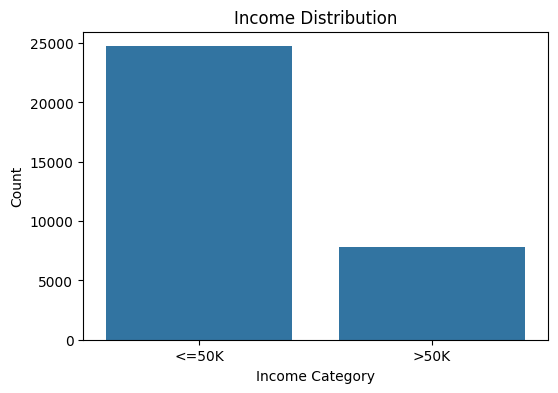

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

#Observation
#The dataset is imbalanced with more individuals earning <=50K compared to >50K.

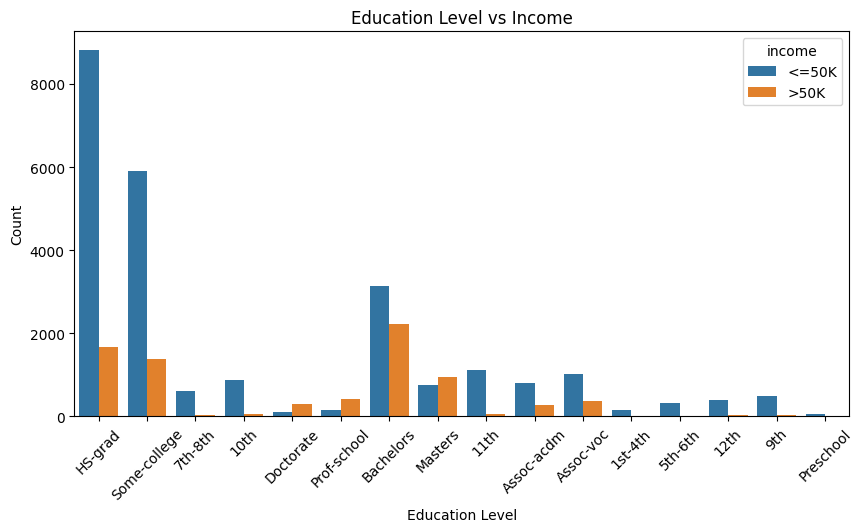

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Education Level vs Income")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

#Observation
#Higher education strongly correlates with higher income.

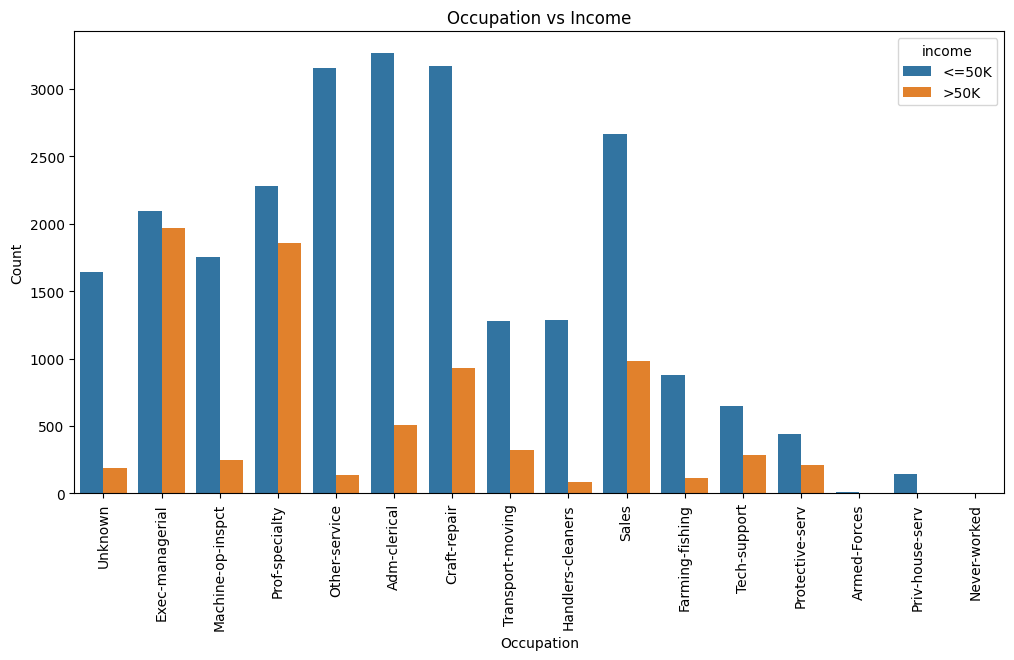

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='occupation', hue='income', data=df)
plt.xticks(rotation=90)
plt.title("Occupation vs Income")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.show()

#Obseravtion
#Occupations requiring technical skills or management roles tend to produce higher income.

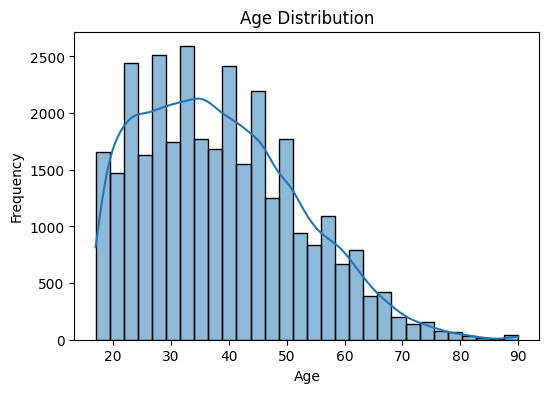

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Observation
#Age might influence income since income generally increases with experience and age up to a point.

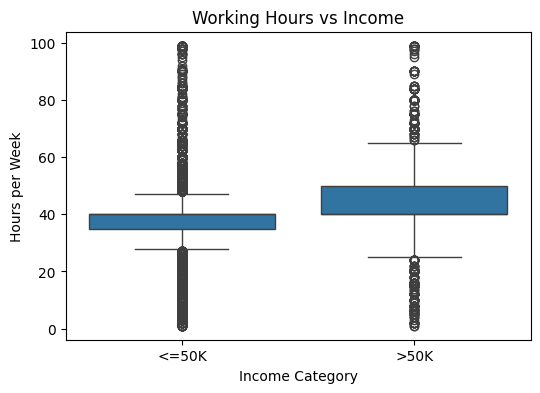

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='hours.per.week', data=df)
plt.title("Working Hours vs Income")
plt.xlabel("Income Category")
plt.ylabel("Hours per Week")
plt.show()

#Observation
#Higher earners tend to work longer hours per week.

In [10]:
mask_never_worked = df['workclass'] == 'Never-worked'
df.loc[mask_never_worked, 'occupation'] = 'Never-worked'

mask_missing = (df['workclass'] == '?') & (df['occupation'] == '?')
df.loc[mask_missing, ['workclass', 'occupation']] = 'Unknown'

In [11]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Preprocessing

In [18]:
X = df.drop(columns = 'income')
y = df['income']

print(X.shape)
print(y.shape)

(32561, 14)
(32561,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26048, 14)
(6513, 14)
(26048,)
(6513,)


In [20]:
# Define categorical and numeric columns

categorical_cols = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]

numeric_cols = [
    'age',
    'fnlwgt',
    'education.num',
    'capital.gain',
    'capital.loss',
    'hours.per.week'
]

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [21]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

print(type(X_train_encoded))

(26048, 100)
(6513, 100)
<class 'numpy.ndarray'>


## Training Decision Tree

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model (controlled depth)
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
model.fit(X_train_encoded, y_train)

# Predict
y_pred = model.predict(X_test_encoded)


### Model Evaluation

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Accuracy: 0.8492246276677414
Confusion Matrix:
[[4707  238]
 [ 744  824]]


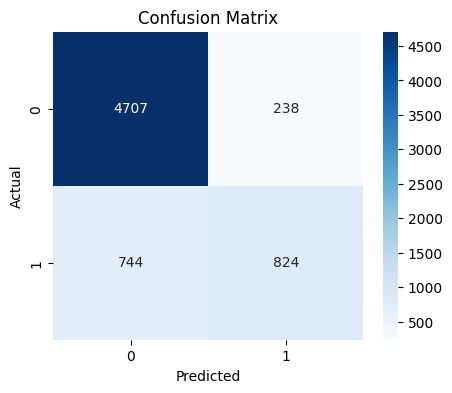

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
##check for overfitting

model.score(X_train_encoded, y_train)

0.8528101965601965

### Controlled Depth Decision Tree

In [26]:
# Create model (controlled depth)
model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
model.fit(X_train_encoded, y_train)

# Predict
y_pred = model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)



Accuracy: 0.7742975587286964
Confusion Matrix:
[[3662 1283]
 [ 187 1381]]


In [27]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # allow trees to grow
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1              # use all cores
)

# Train
rf_model.fit(X_train_encoded, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_encoded)

In [28]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

Accuracy: 0.8587440503608168


In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)


Confusion Matrix:
[[4668  277]
 [ 643  925]]


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,      # number of trees
    max_depth=None,        # allow trees to grow
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1              # use all cores
)

# Train
rf_model.fit(X_train_encoded, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_encoded)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)


Accuracy: 0.8179026562260096
Confusion Matrix:
[[4013  932]
 [ 254 1314]]


### Unsupervised Learning

In [31]:
X_encoded = preprocessor.fit_transform(X)

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)
cluster = kmeans.fit_predict(X_encoded)

df['cluster'] = cluster

In [33]:
df['cluster'].value_counts()

cluster
0    15898
1    11893
2     4770
Name: count, dtype: int64

In [34]:
df.groupby('cluster').mean(numeric_only=True)

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
cluster,,,,,,
0,38.344257,205368.020569,10.058246,1045.518996,85.838911,40.315323
1,39.679812,93509.797780,10.176659,1101.136383,91.558984,40.663415
2,36.634801,377844.984486,9.916143,1126.173585,81.576939,40.281132


In [35]:
pd.crosstab(df['cluster'], df['income'])

income,<=50K,>50K
cluster,,
0,12077,3821
1,8993,2900
2,3650,1120


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['cluster_scaled'] = clusters

In [37]:
df['cluster_scaled'].value_counts()

cluster_scaled
1    15067
2     9192
0     8302
Name: count, dtype: int64

In [38]:
pd.crosstab(df['cluster_scaled'], df['income'])

income,<=50K,>50K
cluster_scaled,,
0,7448,854
1,8301,6766
2,8971,221


In [39]:
df.groupby('cluster_scaled').mean(numeric_only=True)

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,cluster
cluster_scaled,,,,,,,
0,38.390629,191082.028427,10.321971,722.062997,75.104433,40.600096,0.672729
1,43.414017,186332.573040,10.361917,1807.110639,123.885379,43.461870,0.660450
2,30.833225,194249.076806,9.401762,203.113686,38.359661,35.333116,0.641536


### Elbow Method

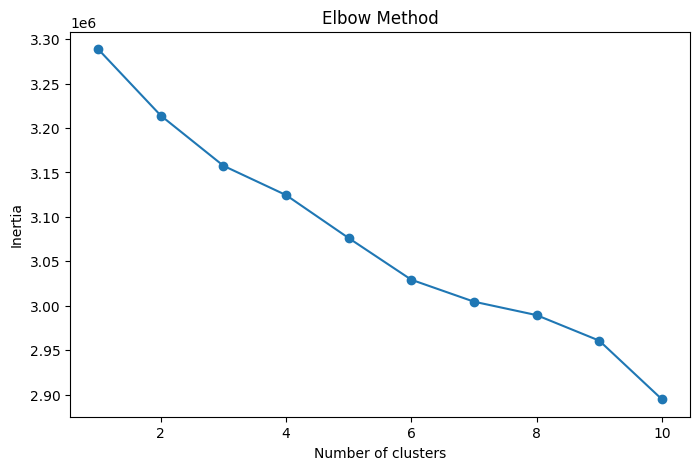

In [40]:
inertia = []

for k in range(1, 11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel('Number of clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()

In [41]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['cluster_optimal'] = clusters

pd.crosstab(df['cluster_optimal'], df['income'])

income,<=50K,>50K
cluster_optimal,,
0,7002,829
1,7532,6477
2,4988,468
3,25,18
4,5173,49


### PCA

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

In [43]:
print(pca.explained_variance_ratio_)
print("Total variance aptured:", sum(pca.explained_variance_ratio_))

[0.03444578 0.02660648]
Total variance aptured: 0.06105225101815326


In [44]:
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

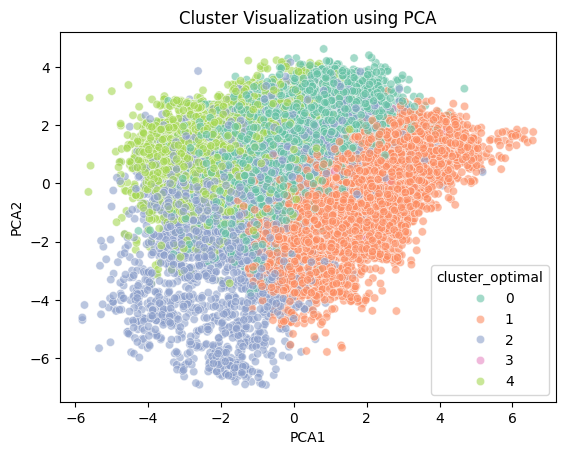

In [45]:
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='cluster_optimal',
    data=df,
    palette='Set2',
    alpha=0.6
)

plt.title("Cluster Visualization using PCA")
plt.show()

## Saving the model

In [55]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "adult_income_pipeline.pkl")

['adult_income_pipeline.pkl']